# Sensibilidad MLP con learning rate menor

Usamos la mejor arquitectura observada (`direct`, predictor `32→64→32`) y cambiamos sólo AdamW de `3e-4` a `1e-4`. Seleccionamos el mínimo error de cada seed, comprobamos el gate formal y medimos clustering en validation. Test no se construye.

In [1]:
# ruff: noqa: E402, E501
import json
import random
import sys
import time
from dataclasses import asdict, replace
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display

from koopman_jepa.paper_config import (
    PaperCheckpointReplayConfig,
    load_paper_mlp_one_hidden_development_config,
)
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import (
    evaluate_paper_mlp_clustering_gate,
    evaluate_paper_mlp_seed_clustering,
)
from koopman_jepa.paper_model import PaperTemporalJEPA
from koopman_jepa.paper_training import (
    evaluate_scale_invariant_seed_stability_gate,
    make_paper_loader,
    run_paper_train_validation_with_checkpoint,
    summarize_seed_checkpoint,
    verify_paper_checkpoint_replay,
)

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_low_lr_development.yaml"
)
selection_gate = replace(config.checkpoint_gate, min_validation_effective_rank=1.0)
replay_config = PaperCheckpointReplayConfig(metric_absolute_tolerance=1e-8)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
assert config.model.encoder_projection == "direct"
assert config.model.mlp_depth == "one_hidden"
assert config.train.learning_rate == 1e-4
assert len(train_dataset) == 64 * len(PAPER_REGIME_NAMES) == 1152
assert len(validation_dataset) == 32 * len(PAPER_REGIME_NAMES) == 576
assert {train_dataset.sample_key(i) for i in range(len(train_dataset))}.isdisjoint(
    {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
)
print(json.dumps(asdict(config), indent=2))
print("Test no fue instanciado.")

{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 64,
    "val_per_regime": 32,
    "test_per_regime": 64,
    "base_seed": 1,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "mlp",
    "linear_initialization": "identity",
    "mlp_depth": "one_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0001,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 20,
    "seed": 10,
    "device": "cpu",
    "num_workers": 0
  },
  "checkpoint_gate": {
    "final_window": 2,
    "max_validation_loss_ratio": 0.5,
    "max_validation_train_loss_ratio": 4.0,
    "min_validation_embedding_std_ratio": 0.1,
    "min_validation_effective_rank": 4.0
  },
  "sweep": {
    "seeds": [
      10,
      11,
      12,
      13,
      14
    ]
  },
  "stability_gate": {
    "max_worst_valid

In [3]:
models, histories, summaries, times = {}, {}, [], {}
for seed in config.sweep.seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    run_config = replace(config.train, seed=seed)
    model = PaperTemporalJEPA(config.model)
    started = time.perf_counter()
    run = run_paper_train_validation_with_checkpoint(
        model, train_dataset, validation_dataset, run_config, selection_gate
    )
    assert run.selection is not None
    replay = verify_paper_checkpoint_replay(
        model, run, validation_dataset, run_config, replay_config, expected_epoch=run.selection.epoch
    )
    assert replay.passed
    times[seed] = time.perf_counter() - started
    models[seed], histories[seed] = model, run.history
    summary = summarize_seed_checkpoint(seed, run.selection)
    summaries.append(summary)
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"seed={seed} epoch={summary.checkpoint_epoch} val/base={summary.validation_loss_ratio:.3f} "
        f"gap={summary.validation_train_loss_ratio:.3f} rank={summary.validation_effective_rank:.2f} "
        f"formal_rank={'PASS' if formal_rank else 'FAIL'}"
    )
predictive_gate = evaluate_scale_invariant_seed_stability_gate(
    summaries, config.sweep, config.stability_gate
)
formal_selection_equivalent = all(
    row.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    for row in summaries
)
predictive_passed = formal_selection_equivalent and predictive_gate.passed
print(f"Predictivo formal: {'PASS' if predictive_passed else 'FAIL'}; tiempo={sum(times.values()):.1f}s")
print(json.dumps(asdict(predictive_gate), indent=2))

seed=10 epoch=8 val/base=0.019 gap=1.090 rank=7.32 formal_rank=PASS


seed=11 epoch=10 val/base=0.011 gap=1.045 rank=1.60 formal_rank=FAIL


seed=12 epoch=7 val/base=0.021 gap=1.062 rank=3.92 formal_rank=FAIL


seed=13 epoch=8 val/base=0.028 gap=1.091 rank=2.44 formal_rank=FAIL


seed=14 epoch=9 val/base=0.016 gap=1.101 rank=3.14 formal_rank=FAIL
Predictivo formal: FAIL; tiempo=199.9s
{
  "all_checkpoints_selected": true,
  "all_finite": true,
  "mean_validation_loss_ratio": 0.01927782594270077,
  "validation_loss_ratio_coefficient_of_variation": 0.2867853632497676,
  "absolute_validation_loss_coefficient_of_variation": 0.1369015051522014,
  "worst_validation_loss_ratio": 0.028008337155402085,
  "worst_validation_train_loss_ratio": 1.1012011114176037,
  "worst_validation_embedding_std_ratio": 3.339883841171458,
  "worst_validation_effective_rank": 1.6030395030975342,
  "validation_loss_passed": true,
  "generalization_gap_passed": true,
  "variability_passed": false,
  "spread_passed": true,
  "rank_passed": false,
  "passed": false
}


In [4]:
@torch.no_grad()
def collect_embeddings(model, run_config):
    device = torch.device(run_config.device)
    model.to(device).eval()
    embeddings, labels = [], []
    for context, _, batch_labels in make_paper_loader(validation_dataset, run_config, shuffle=False):
        embeddings.append(model.online_encoder(context.to(device)).cpu().numpy())
        labels.append(batch_labels.numpy())
    return np.concatenate(embeddings), np.concatenate(labels)

clustering_metrics, reference_labels = [], None
for seed in config.sweep.seeds:
    embeddings, labels = collect_embeddings(models[seed], replace(config.train, seed=seed))
    reference_labels = labels if reference_labels is None else reference_labels
    assert np.array_equal(labels, reference_labels)
    clustering_metrics.append(
        evaluate_paper_mlp_seed_clustering(embeddings, labels, seed, config.clustering)
    )
clustering_gate = evaluate_paper_mlp_clustering_gate(
    clustering_metrics, config.sweep, config.clustering_gate
)
development_passed = predictive_passed and clustering_gate.passed
print(json.dumps(asdict(clustering_gate), indent=2))
print(f"Resultado conjunto: {'PASS' if development_passed else 'FAIL'}")
print("Test no fue construido ni consultado.")

{
  "all_seeds_present": true,
  "all_finite": true,
  "overall_mean_purity": 0.5112847222222221,
  "worst_seed_mean_purity": 0.48185763888888883,
  "seed_mean_purity_coefficient_of_variation": 0.04109304134861253,
  "worst_within_seed_purity_std": 0.013620176172782179,
  "failed_seeds": [
    10,
    11,
    12,
    13,
    14
  ],
  "overall_mean_passed": false,
  "worst_seed_passed": false,
  "seed_variability_passed": true,
  "kmeans_stability_passed": true,
  "metrics": [
    {
      "seed": 10,
      "mean_purity": 0.4927083333333333,
      "purity_std": 0.005953620902598006,
      "minimum_purity": 0.4809027777777778,
      "maximum_purity": 0.5052083333333334,
      "mean_matched_accuracy": 0.4603298611111112,
      "purities": [
        0.4930555555555556,
        0.4930555555555556,
        0.5,
        0.4913194444444444,
        0.4930555555555556,
        0.4930555555555556,
        0.4930555555555556,
        0.5034722222222222,
        0.4947916666666667,
        0.48263

seed epoch val/base rank formal_rank purity_mean purity_sd
  10     8    0.019  7.32        True      49.27%     0.60%
  11    10    0.011  1.60       False      53.95%     0.90%
  12     7    0.021  3.92       False      52.27%     1.36%
  13     8    0.028  2.44       False      51.97%     1.26%
  14     9    0.016  3.14       False      48.19%     1.05%


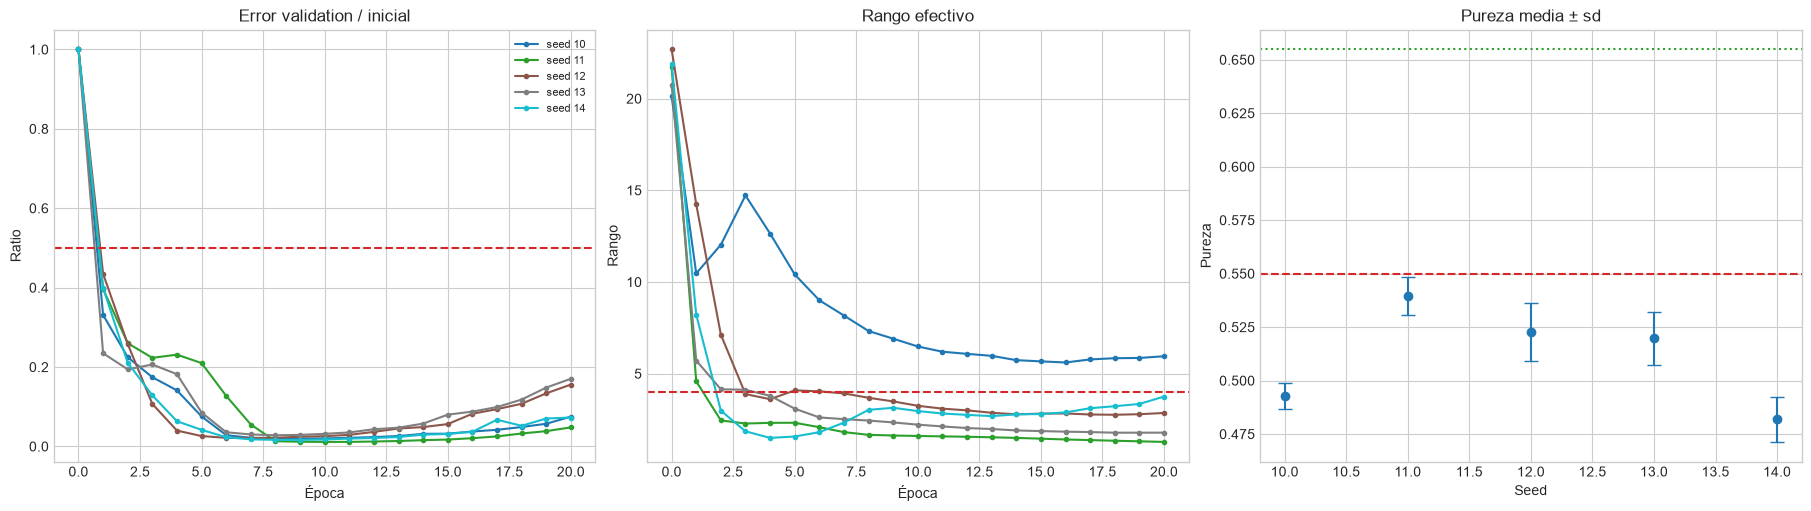

## Veredicto

- Selección: **descriptiva por rango fallido**.
- Gate predictivo: **FAIL**.
- Pureza global: **51.13%**.
- Peor seed: **48.19%**.
- Gate conjunto: **FAIL**.

Test no fue construido ni consultado.


In [5]:
summary_by_seed = {row.seed: row for row in summaries}
cluster_by_seed = {row.seed: row for row in clustering_metrics}
print("seed epoch val/base rank formal_rank purity_mean purity_sd")
for seed in config.sweep.seeds:
    summary, cluster = summary_by_seed[seed], cluster_by_seed[seed]
    formal_rank = summary.validation_effective_rank >= config.checkpoint_gate.min_validation_effective_rank
    print(
        f"{seed:>4d} {summary.checkpoint_epoch:>5d} {summary.validation_loss_ratio:>8.3f} "
        f"{summary.validation_effective_rank:>5.2f} {str(formal_rank):>11s} "
        f"{cluster.mean_purity:>11.2%} {cluster.purity_std:>9.2%}"
    )

seeds = np.array(config.sweep.seeds)
means = np.array([cluster_by_seed[seed].mean_purity for seed in seeds])
stds = np.array([cluster_by_seed[seed].purity_std for seed in seeds])
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(seeds)))
for color, seed in zip(colors, seeds, strict=True):
    history = histories[seed]
    epochs = np.array([row.epoch for row in history])
    losses = np.array([row.validation_loss for row in history])
    ranks = np.array([row.validation_effective_rank for row in history])
    axes[0].plot(epochs, losses / losses[0], marker="o", markersize=3, color=color, label=f"seed {seed}")
    axes[1].plot(epochs, ranks, marker="o", markersize=3, color=color)
axes[0].axhline(config.checkpoint_gate.max_validation_loss_ratio, color="tab:red", linestyle="--")
axes[0].set(title="Error validation / inicial", xlabel="Época", ylabel="Ratio")
axes[0].legend(fontsize=8)
axes[1].axhline(config.checkpoint_gate.min_validation_effective_rank, color="tab:red", linestyle="--")
axes[1].set(title="Rango efectivo", xlabel="Época", ylabel="Rango")
axes[2].errorbar(seeds, means, yerr=stds, fmt="o", capsize=5)
axes[2].axhline(config.clustering_gate.min_worst_seed_mean_purity, color="tab:red", linestyle="--")
axes[2].axhline(0.6548, color="tab:green", linestyle=":")
axes[2].set(title="Pureza media ± sd", xlabel="Seed", ylabel="Pureza")
plt.show()

selection_label = "formal" if formal_selection_equivalent else "descriptiva por rango fallido"
display(Markdown(f"""## Veredicto

- Selección: **{selection_label}**.
- Gate predictivo: **{'PASS' if predictive_passed else 'FAIL'}**.
- Pureza global: **{clustering_gate.overall_mean_purity:.2%}**.
- Peor seed: **{clustering_gate.worst_seed_mean_purity:.2%}**.
- Gate conjunto: **{'PASS' if development_passed else 'FAIL'}**.

Test no fue construido ni consultado.
"""))

## Análisis posterior a la corrida

Bajar el learning rate desplaza los mínimos predictivos de épocas 5–7 a épocas 7–10, pero no resuelve la representación. Sólo seed 10 queda por encima del rango formal (`7.32`); seed 12 queda cerca (`3.92`) y las demás entre `1.60` y `3.14`. El CV del ratio de error también falla por poco (`0.287` frente a `0.25`).

La pureza global es `51.13%`, apenas `0.37` puntos por encima del baseline `3e-4` (`50.76%`). La peor seed mejora de `47.60%` a `48.19%`, pero las cinco medias siguen por debajo del mínimo local de `55%`; la mejor alcanza `53.95%`. La variación permanece baja (CV `0.041`, peor sd K-means `1.36%`), por lo que la mejora diminuta no está escondiendo un run afortunado.

Conclusión: pasos más pequeños con el mismo presupuesto no explican la brecha de aproximadamente 14 puntos con el paper. Ya evaluamos las ambigüedades principales de predictor y encoder y una sensibilidad de learning rate. La diferencia experimental más grande que queda es la cantidad de datos: este desarrollo usa sólo 64 secuencias train por régimen, muy lejos de la escala publicada. El próximo experimento debe ser un piloto de escalado de datos con la mejor configuración base, no otra búsqueda local de arquitectura.